Exposure matrix shape: (150, 150)
Initial capital vector:
[28.72 32.88 30.07 28.62 25.59 31.15 25.94 37.29 39.09 24.59 34.79 28.22
 29.2  38.14 16.78 17.18 15.51 35.82 34.45 36.75 39.47 34.98 26.54 34.51
 17.96 31.   18.58 38.62 28.05 25.37 21.61 34.36 26.4  29.21 15.47 30.44
 30.3  30.42 38.59 32.05 23.99 25.93 32.44 16.51 31.67 31.77 20.26 18.22
 22.89 24.09 29.25 25.97 39.71 17.55 20.22 19.03 31.33 21.33 26.66 21.11
 18.97 17.76 31.41 18.45 19.91 24.22 35.52 17.43 35.95 17.4  39.41 26.72
 39.42 30.12 33.48 15.98 22.07 18.   22.4  17.97 22.95 25.36 16.6  32.31
 29.17 21.63 28.08 17.35 29.4  38.23 22.96 31.69 18.29 32.91 22.24 19.58
 29.66 15.5  35.72 15.12 31.95 21.75 33.38 39.05 21.22 29.4  29.8  29.31
 20.58 38.82 26.18 36.16 32.49 22.44 35.34 24.91 37.03 29.53 37.04 32.31
 33.13 27.53 38.9  31.1  25.6  30.16 15.48 22.54 31.5  22.25 30.45 25.72
 18.39 22.46 29.25 29.77 29.36 31.33 31.3  25.79 37.41 24.19 25.9  37.3
 35.15 32.6  17.51 37.99 32.86 39.97]

Final counts:
Healthy: 0
Dis

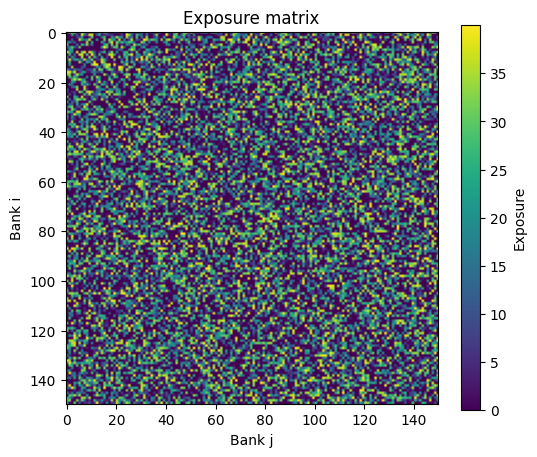

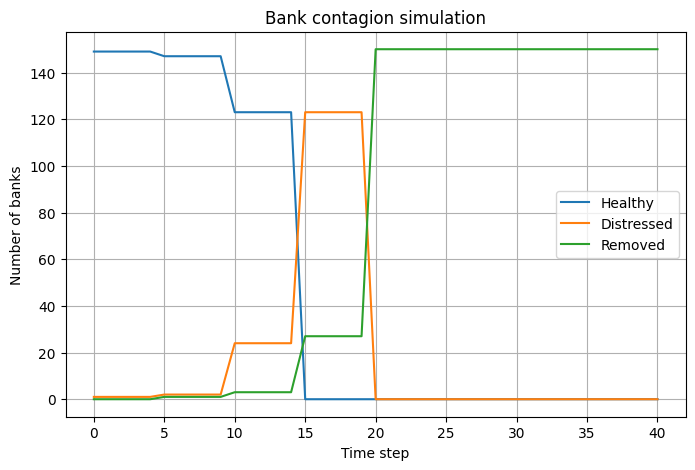

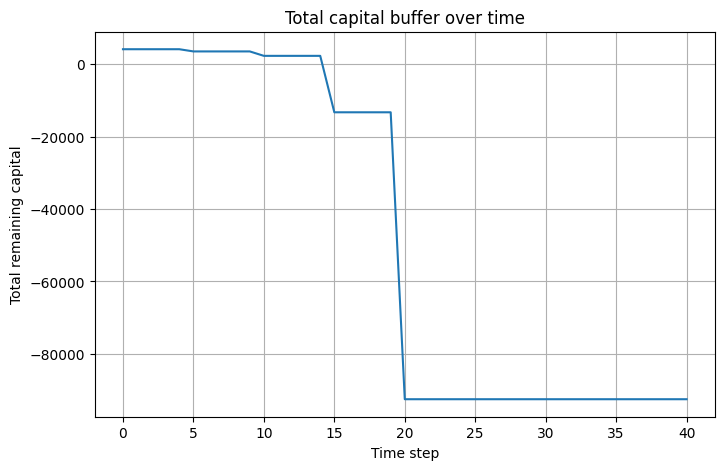

In [38]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# =========================================================
# PARAMETERS
# =========================================================

N_BANKS = 150
TIME_STEPS = 40

LOSS_FRACTION = 0.35
THRESHOLD_FRACTION = 0.75
DISTRESS_DURATION = 5   # number of steps a bank stays distressed before defaulting

# State meanings:
# 0 = Healthy
# 1 = Distressed
# 2 = Removed / Defaulted


# =========================================================
# DATA GENERATION
# =========================================================

def generate_capital(n, min_capital=15.0, max_capital=40.0):
    return np.random.uniform(min_capital, max_capital, size=n)


def generate_exposure_matrix(n, connection_prob=0.08, max_exposure=8.0):
    E = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i != j and np.random.rand() < connection_prob:
                E[i, j] = np.random.uniform(1.0, max_exposure)

    return E


# =========================================================
# MODEL LOGIC
# =========================================================

def compute_new_default_losses(newly_defaulted, exposure_matrix, loss_fraction):
    """
    Apply losses only from banks that defaulted THIS step.

    newly_defaulted[j] = 1 if bank j has just moved from distressed to removed.

    Then each bank i takes a one-off hit:
        loss_fraction * E[i, j]
    summed over newly defaulted banks j.
    """
    return loss_fraction * (exposure_matrix @ newly_defaulted.astype(float))


def update_system(states, distress_age, capital_buffer, initial_capital,
                  exposure_matrix, loss_fraction, threshold_fraction, distress_duration):
    """
    One full update step.

    Inputs:
    - states: bank states (0 healthy, 1 distressed, 2 removed)
    - distress_age: how many steps each bank has been distressed
    - capital_buffer: remaining capital after losses
    - exposure_matrix: E[i,j] exposure of i to j
    - loss_fraction: fraction of exposure lost on counterparty default
    - threshold_fraction: bank becomes distressed if remaining capital falls below
                          (1 - threshold_fraction) * initial capital
    - distress_duration: number of steps a bank stays distressed before defaulting

    Returns:
    - new_states
    - new_distress_age
    - new_capital_buffer
    """
    n = len(states)
    new_states = states.copy()
    new_distress_age = distress_age.copy()
    new_capital_buffer = capital_buffer.copy()

    # -----------------------------------------------------
    # 1. Banks that have been distressed long enough default now
    # -----------------------------------------------------
    newly_defaulted = np.zeros(n, dtype=bool)

    for i in range(n):
        if states[i] == 1:
            new_distress_age[i] += 1
            if new_distress_age[i] >= distress_duration:
                new_states[i] = 2
                newly_defaulted[i] = True

    # -----------------------------------------------------
    # 2. Apply one-off losses from these newly defaulted banks
    # -----------------------------------------------------
    losses = compute_new_default_losses(newly_defaulted, exposure_matrix, loss_fraction)
    new_capital_buffer -= losses

    # -----------------------------------------------------
    # 3. Healthy banks become distressed if capital buffer falls too low
    # -----------------------------------------------------

    for i in range(n):
        if new_states[i] == 0:
            if new_capital_buffer[i] < (1 - threshold_fraction) * initial_capital[i]:
                new_states[i] = 1
                new_distress_age[i] = 0

    return new_states, new_distress_age, new_capital_buffer


def run_simulation(exposure_matrix, initial_capital, initial_distressed,
                   time_steps, loss_fraction, threshold_fraction, distress_duration):
    """
    Run the contagion simulation.

    We track:
    - states
    - distress age
    - remaining capital buffer

    Important:
    - losses are only applied once, when a bank newly defaults
    - distressed banks stay distressed for several steps before defaulting
    """
    n = len(initial_capital)

    states = np.zeros(n, dtype=int)
    distress_age = np.zeros(n, dtype=int)
    capital_buffer = initial_capital.copy()

    for idx in initial_distressed:
        states[idx] = 1
        distress_age[idx] = 0

    state_history = [states.copy()]
    capital_history = [capital_buffer.copy()]

    for _ in range(time_steps):
        states, distress_age, capital_buffer = update_system(
            states=states,
            distress_age=distress_age,
            capital_buffer=capital_buffer,
            initial_capital=initial_capital,
            exposure_matrix=exposure_matrix,
            loss_fraction=loss_fraction,
            threshold_fraction=threshold_fraction,
            distress_duration=distress_duration
        )

        state_history.append(states.copy())
        capital_history.append(capital_buffer.copy())

    return np.array(state_history), np.array(capital_history)


# =========================================================
# ANALYSIS HELPERS
# =========================================================

def count_states(history):
    healthy_counts = np.sum(history == 0, axis=1)
    distressed_counts = np.sum(history == 1, axis=1)
    removed_counts = np.sum(history == 2, axis=1)
    return healthy_counts, distressed_counts, removed_counts


def print_summary(exposure_matrix, capital, history, capital_history):
    print("Exposure matrix shape:", exposure_matrix.shape)
    print("Initial capital vector:")
    print(np.round(capital, 2))

    healthy_counts, distressed_counts, removed_counts = count_states(history)

    print("\nFinal counts:")
    print("Healthy:", healthy_counts[-1])
    print("Distressed:", distressed_counts[-1])
    print("Removed:", removed_counts[-1])

    print("\nFinal capital buffer:")
    print(np.round(capital_history[-1], 2))


# =========================================================
# PLOTTING
# =========================================================

def plot_state_counts(history):
    healthy_counts, distressed_counts, removed_counts = count_states(history)
    t = np.arange(len(history))

    plt.figure(figsize=(8, 5))
    plt.plot(t, healthy_counts, label="Healthy")
    plt.plot(t, distressed_counts, label="Distressed")
    plt.plot(t, removed_counts, label="Removed")
    plt.xlabel("Time step")
    plt.ylabel("Number of banks")
    plt.title("Bank contagion simulation")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_exposure_matrix(exposure_matrix):
    plt.figure(figsize=(6, 5))
    plt.imshow(exposure_matrix)
    plt.colorbar(label="Exposure")
    plt.title("Exposure matrix")
    plt.xlabel("Bank j")
    plt.ylabel("Bank i")
    plt.show()


def plot_total_capital(capital_history):
    total_capital = np.sum(capital_history, axis=1)
    t = np.arange(len(capital_history))

    plt.figure(figsize=(8, 5))
    plt.plot(t, total_capital)
    plt.xlabel("Time step")
    plt.ylabel("Total remaining capital")
    plt.title("Total capital buffer over time")
    plt.grid(True)
    plt.show()


# =========================================================
# MAIN
# =========================================================

capital_buffer_initial = generate_capital(N_BANKS)

exposure_matrix = generate_exposure_matrix(
    N_BANKS,
    connection_prob=0.6,
    max_exposure=40.0
)

initial_distressed = [0]

history, capital_history = run_simulation(
    exposure_matrix=exposure_matrix,
    initial_capital=capital_buffer_initial,
    initial_distressed=initial_distressed,
    time_steps=TIME_STEPS,
    loss_fraction=LOSS_FRACTION,
    threshold_fraction=THRESHOLD_FRACTION,
    distress_duration=DISTRESS_DURATION
)

print_summary(exposure_matrix, capital_buffer_initial, history, capital_history)
plot_exposure_matrix(exposure_matrix)
plot_state_counts(history)
plot_total_capital(capital_history)

In [40]:
results = []

for seed in range(30):
    np.random.seed(seed)

    capital = generate_capital(N_BANKS)
    E = generate_exposure_matrix(N_BANKS, connection_prob=0.1, max_exposure=8.0)

    history, capital_history = run_simulation(
        exposure_matrix=E,
        initial_capital=capital,
        initial_distressed=[0],
        time_steps=TIME_STEPS,
        loss_fraction=LOSS_FRACTION,
        threshold_fraction=THRESHOLD_FRACTION,
        distress_duration=DISTRESS_DURATION
    )

    healthy_counts, distressed_counts, removed_counts = count_states(history)
    results.append(removed_counts[-1])

print(results)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
